# ESG Corpus TF-IDF Vector Exploration

Each ESG reference corpus (E, S, G) has been projected into the bigram TF-IDF space of the earnings-call transcripts.

| Column | Formula |
|---|---|
| **tf** | $f(b, c)$ — raw bigram count in the corpus |
| **idf** | $\log\!\left(\dfrac{T}{df_{\text{transcript}}(b)}\right)$ |
| **tf-idf** | $tf \times idf$ |
| **tf-idf (norm)** | min-max normalised tf-idf over the displayed bigrams |

Choose `SEGMENT` to switch between `combined`, `pres`, and `answers`.  
Choose `TOP_N` to control how many top bigrams to display per corpus.

In [8]:
import math
import csv
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_rows", 60)

PROJECT_ROOT = Path("..").resolve()
PROC_DIR     = PROJECT_ROOT / "data" / "processed"
VECTORS_DIR  = PROC_DIR / "esg_corpus_vectors"

# ── configuration ──────────────────────────────────────────────────────────
SEGMENT = "combined"   # "combined" | "pres" | "answers"
TOP_N   = 30           # top bigrams shown per corpus in the table
# ───────────────────────────────────────────────────────────────────────────

CORPORA = ("E", "S", "G")
CORPUS_LABELS = {"E": "Environment", "S": "Social", "G": "Governance"}

print(f"Segment : {SEGMENT}")
print(f"Top-N   : {TOP_N}")

Segment : combined
Top-N   : 30


## Load vocab and recover IDF

Load the transcript vocabulary and reconstruct $IDF(b) = \log(T / df(b))$ from the sparse transcript matrix (column-wise nnz).

In [9]:
# Load vocab: index → bigram
vocab_path = PROC_DIR / f"bigram_vocab_{SEGMENT}.csv"
idx_to_bigram: list[str] = [""] * 0   # will be built below
bigram_to_idx: dict[str, int] = {}

with open(vocab_path, newline="", encoding="utf-8") as fh:
    reader = csv.reader(fh)
    next(reader)
    rows_v = list(reader)

idx_to_bigram = [""] * len(rows_v)
for row in rows_v:
    j = int(row[0])
    idx_to_bigram[j] = row[1]
    bigram_to_idx[row[1]] = j

V = len(idx_to_bigram)
print(f"Vocabulary size : {V:,}")

# Load transcript matrix and recover df per bigram
mat = sp.load_npz(str(PROC_DIR / f"bigram_tfidf_{SEGMENT}.npz"))
T   = mat.shape[0]
print(f"Transcripts     : {T:,}")

col_nnz = np.diff(mat.tocsc().indptr)   # col_nnz[j] = df for bigram j
print(f"Non-zero columns: {int((col_nnz > 0).sum()):,}")

del mat   # free memory — we only need col_nnz

Vocabulary size : 11,948,551
Transcripts     : 23,121
Non-zero columns: 11,948,551


## Coverage statistics

How many of the corpus bigrams appear in the transcript vocabulary?

In [10]:
stats_path = VECTORS_DIR / f"corpus_stats_{SEGMENT}.csv"
df_stats = pd.read_csv(stats_path)
df_stats["pct_in_vocab"] = (
    df_stats["bigrams_in_vocab"]
    / (df_stats["bigrams_in_vocab"] + df_stats["bigrams_oov"])
    * 100
).round(1)
df_stats["corpus_name"] = df_stats["corpus"].map(CORPUS_LABELS)
df_stats[["corpus_name", "bigrams_in_vocab", "bigrams_oov",
          "pct_in_vocab", "total_tfidf_mass"]]

,corpus_name,bigrams_in_vocab,bigrams_oov,pct_in_vocab,total_tfidf_mass
0,Environment,8750,12598,41.0000,138094.2500
1,Social,7116,7455,48.8000,80989.9900
2,Governance,6959,5125,57.6000,72382.1200


## Top bigrams per corpus

Load each ESG corpus vector and display the highest TF-IDF bigrams.

$$TFIDF(b, c) = f(b, c) \times \log\!\left(\frac{T}{df_{\text{transcript}}(b)}\right)$$

In [11]:
def load_top_n(corpus_label: str, n: int) -> pd.DataFrame:
    """Load corpus vector and return top-N bigrams by TF-IDF."""
    vec_path = VECTORS_DIR / f"corpus_tfidf_{SEGMENT}_{corpus_label}.npz"
    vec = sp.load_npz(str(vec_path)).tocsr()  # (1, V)

    # non-zero entries
    nz_cols = vec.indices
    nz_vals = vec.data

    # sort descending by tfidf
    order = np.argsort(nz_vals)[::-1][:n]
    rows_out = []
    for o in order:
        j       = int(nz_cols[o])
        bigram  = idx_to_bigram[j]
        df_b    = int(col_nnz[j])
        idf_b   = math.log(T / df_b)
        tfidf_b = float(nz_vals[o])
        tf_b    = tfidf_b / idf_b            # back-compute raw tf
        rows_out.append({
            "bigram":  bigram,
            "tf":      round(tf_b),
            "idf":     idf_b,
            "tf-idf":  tfidf_b,
        })

    df = pd.DataFrame(rows_out)
    tmin, tmax = df["tf-idf"].min(), df["tf-idf"].max()
    df["tf-idf (norm)"] = ((df["tf-idf"] - tmin) / (tmax - tmin)
                            if tmax > tmin else 0.0)
    return df


for corp in CORPORA:
    print(f"\n{'─'*60}")
    print(f"  {CORPUS_LABELS[corp]} ({corp})  —  segment: {SEGMENT}")
    print(f"{'─'*60}")
    display(load_top_n(corp, TOP_N))


────────────────────────────────────────────────────────────
  Environment (E)  —  segment: combined
────────────────────────────────────────────────────────────


,bigram,tf,idf,tf-idf,tf-idf (norm)
0,global warming,189,6.7904,1283.3856,1.0000
1,climate change,224,4.9733,1114.0243,0.8479
2,sea level,86,8.1026,696.8224,0.4731
3,mitigation adaptation,73,9.3553,682.9405,0.4607
4,surface temperature,62,10.0485,623.0068,0.4068
5,net zero,104,5.6540,588.0209,0.3754
6,level rise,66,8.6622,571.7053,0.3608
7,global surface,66,8.6622,571.7053,0.3608
8,sustainable development,68,7.8513,533.8865,0.3268
9,climate action,48,7.7459,371.8037,0.1812



────────────────────────────────────────────────────────────
  Social (S)  —  segment: combined
────────────────────────────────────────────────────────────


,bigram,tf,idf,tf-idf,tf-idf (norm)
0,multinational enterprises,90,8.9499,805.4896,1.0000
1,business conduct,100,7.3404,734.0446,0.8999
2,responsible business,99,6.9130,684.3872,0.8303
3,human rights,62,7.3404,455.1077,0.5091
4,specific instances,42,7.5636,317.6708,0.3166
5,adverse impacts,50,6.0412,302.0582,0.2947
6,specific instance,37,8.1026,299.7957,0.2916
7,due diligence,78,3.3752,263.2655,0.2404
8,matters covered,25,10.0485,251.2124,0.2235
9,implementation guidelines,27,8.2567,222.9319,0.1839



────────────────────────────────────────────────────────────
  Governance (G)  —  segment: combined
────────────────────────────────────────────────────────────


,bigram,tf,idf,tf-idf,tf-idf (norm)
0,corporate governance,161,4.6369,746.5330,1.0000
1,board members,75,5.1733,387.9974,0.4613
2,governance framework,39,8.9499,349.0455,0.4028
3,many jurisdictions,31,6.8296,211.7182,0.1964
4,party transactions,21,9.3553,196.4623,0.1735
5,conflicts interest,29,6.7163,194.7725,0.1710
6,good practice,25,6.6812,167.0300,0.1293
7,related party,24,6.0054,144.1307,0.0949
8,key executives,24,5.9881,143.7133,0.0942
9,voting rights,19,6.8296,129.7628,0.0733


## Top-bigram bar charts

Visualise the top-15 bigrams per corpus ranked by TF-IDF.

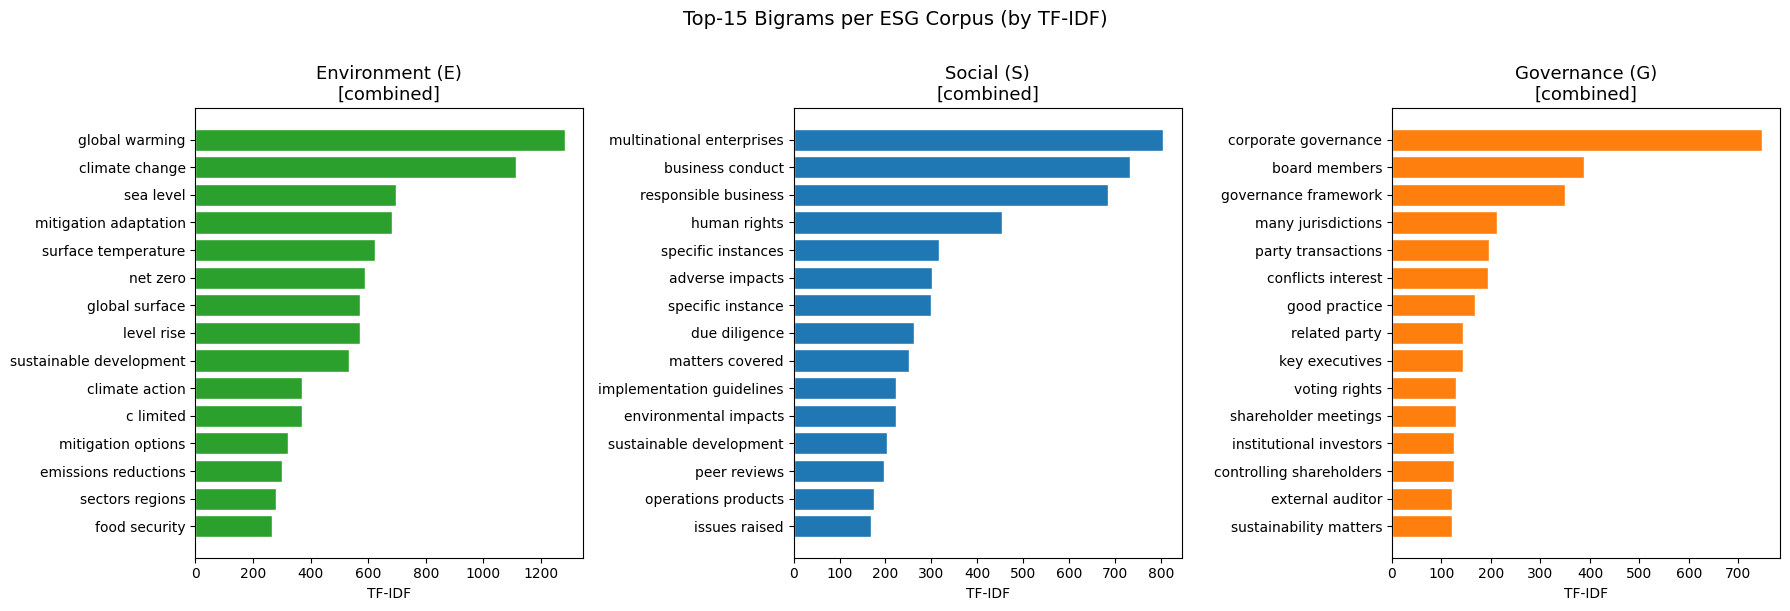

Saved → reports/figures/esg_top_bigrams_combined.png


In [12]:
import matplotlib.pyplot as plt

CHART_N = 15   # bigrams per panel
COLORS  = {"E": "#2ca02c", "S": "#1f77b4", "G": "#ff7f0e"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, corp in zip(axes, CORPORA):
    df_plot = load_top_n(corp, CHART_N).sort_values("tf-idf")
    ax.barh(df_plot["bigram"], df_plot["tf-idf"],
            color=COLORS[corp], edgecolor="white")
    ax.set_title(f"{CORPUS_LABELS[corp]} ({corp})\n[{SEGMENT}]", fontsize=13)
    ax.set_xlabel("TF-IDF")
    ax.tick_params(axis="y", labelsize=10)

fig.suptitle("Top-15 Bigrams per ESG Corpus (by TF-IDF)", fontsize=14, y=1.01)
fig.tight_layout()

figures_dir = Path("..") / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figures_dir / f"esg_top_bigrams_{SEGMENT}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → reports/figures/esg_top_bigrams_{SEGMENT}.png")

## Pairwise cosine similarity between E, S, G vectors

How much vocabulary overlap is there between the reference corpora?

$$\cos(u, v) = \frac{u \cdot v}{\|u\| \|v\|}$$

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

vecs = {}
for corp in CORPORA:
    vec_path = VECTORS_DIR / f"corpus_tfidf_{SEGMENT}_{corp}.npz"
    vecs[corp] = sp.load_npz(str(vec_path))   # (1, V) sparse

# stack → (3, V) and compute cosine similarity matrix
stacked = sp.vstack([vecs[c] for c in CORPORA])
sim_matrix = cosine_similarity(stacked)   # dense (3, 3)

df_sim = pd.DataFrame(
    sim_matrix,
    index=[CORPUS_LABELS[c] for c in CORPORA],
    columns=[CORPUS_LABELS[c] for c in CORPORA],
)
df_sim

,Environment,Social,Governance
Environment,1.0000,0.0612,0.0141
Social,0.0612,1.0000,0.0972
Governance,0.0141,0.0972,1.0000


## TF-IDF mass across all sets

Compare the total TF-IDF mass for E, S, G across `combined`, `pres`, and `answers` segments.

Total TF-IDF mass per set:



set,combined,pres,answers
corpus_name,,,
Environment,"138,094.2","126,570.4","117,667.0"
Governance,"72,382.1","65,666.7","64,326.3"
Social,"80,990.0","73,552.7","69,571.3"


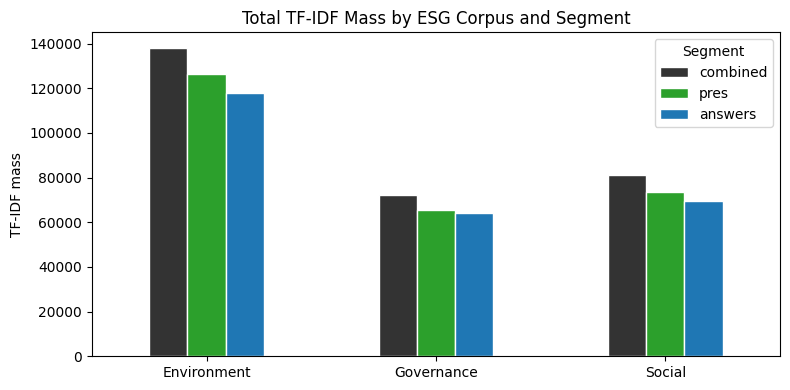

Saved → reports/figures/esg_tfidf_mass_by_segment.png


In [14]:
all_stats = []
for seg in ("combined", "pres", "answers"):
    sp_path = VECTORS_DIR / f"corpus_stats_{seg}.csv"
    df_s = pd.read_csv(sp_path)
    df_s["set"] = seg
    all_stats.append(df_s)

df_all = pd.concat(all_stats, ignore_index=True)
df_all["corpus_name"] = df_all["corpus"].map(CORPUS_LABELS)

# Pivot for display
pivot = df_all.pivot_table(
    index="corpus_name", columns="set",
    values="total_tfidf_mass", aggfunc="sum"
)[["combined", "pres", "answers"]]
print("Total TF-IDF mass per set:\n")
display(pivot.style.format("{:,.1f}"))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind="bar", ax=ax, color=["#333333", "#2ca02c", "#1f77b4"],
           edgecolor="white")
ax.set_title("Total TF-IDF Mass by ESG Corpus and Segment")
ax.set_xlabel("")
ax.set_ylabel("TF-IDF mass")
ax.legend(title="Segment")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(figures_dir / "esg_tfidf_mass_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/figures/esg_tfidf_mass_by_segment.png")